# Isolation Forest — Cybersecurity Anomaly Detection

End-to-end CPU-safe anomaly detection demo: synthetic security events → preprocessing → IsolationForest → scoring + ROC-AUC.

_Last rebuild: **2026-02-16 03:48:35**_

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(10,4)


In [2]:
# Synthetic security-like events
N=6000
# normal traffic
bytes_in = np.random.lognormal(mean=10.0, sigma=0.35, size=N)
bytes_out = np.random.lognormal(mean=9.6, sigma=0.40, size=N)
failed_logins = np.random.poisson(0.2, size=N)
ports = np.random.choice([22,80,443,3389,445,53,8080], size=N, p=[0.05,0.35,0.35,0.05,0.05,0.10,0.05])

# inject anomalies
anom = np.random.rand(N) < 0.03
bytes_in[anom] *= np.random.uniform(6, 20, size=anom.sum())
failed_logins[anom] += np.random.poisson(8, size=anom.sum())
ports[anom] = np.random.choice([23,5900,4444,6667], size=anom.sum())

df = pd.DataFrame({
    'bytes_in': bytes_in,
    'bytes_out': bytes_out,
    'failed_logins': failed_logins,
    'port': ports,
    'is_anomaly': anom.astype(int)
})

df.head()

,bytes_in,bytes_out,failed_logins,port,is_anomaly
0,26208.785384,9455.647459,0,3389,0
1,20985.930051,11471.576733,0,22,0
2,27630.927566,10129.182839,0,443,0
3,37536.176355,11858.517592,0,443,0
4,20293.305227,13552.683835,1,53,0


C:\Users\Olivier Robert\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:409: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


ROC-AUC: 0.9999847269950363


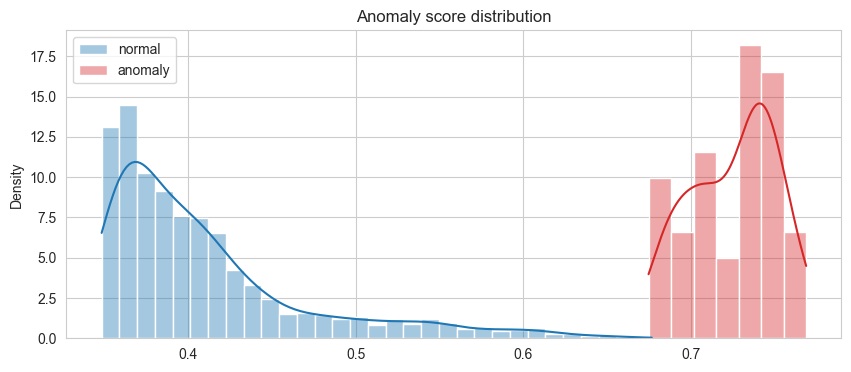

In [3]:
X = df[['bytes_in','bytes_out','failed_logins','port']]
y = df['is_anomaly']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

iso = IsolationForest(n_estimators=300, contamination=float(y_train.mean()), random_state=42)
iso.fit(X_train)

# IsolationForest: higher score => more normal. We invert to get anomaly score.
score = -iso.score_samples(X_test)
print('ROC-AUC:', roc_auc_score(y_test, score))

sns.histplot(score[y_test==0], label='normal', kde=True, stat='density', color='C0', alpha=0.4)
sns.histplot(score[y_test==1], label='anomaly', kde=True, stat='density', color='C3', alpha=0.4)
plt.title('Anomaly score distribution')
plt.legend(); plt.show()

In [4]:
print('DONE 2026-02-16 03:48:35')

DONE 2026-02-16 03:48:35
